# S&P 500 Diskrete Mathematik und Stochastik

In [546]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np

# Immer helle Diagramme
plt.style.use('default')

### 1. Daten laden (Index)
Der Datensatz stammt von https://www.kaggle.com/datasets/andrewmvd/sp-500-stocks/versions/1022

Dabei werden  die Dateien  sp500_companies.csv, sp500_index.csv und sp500_stocks.csv geliefert. Die neuste Version enthält dfabei nicht alle Daten und wird hier nicht verwendet.

In [547]:
# Daten laden --> Erst werden nur die Indexdaten betrachtet
df = pd.read_csv('data2/sp500_index.csv')

In [548]:
# Erster Dateneinblick
print(df.head())
print(df.info())
print(df.describe())

         Date   S&P500
0  2014-12-22  2078.54
1  2014-12-23  2082.17
2  2014-12-24  2081.88
3  2014-12-26  2088.77
4  2014-12-29  2090.57
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2517 non-null   object 
 1   S&P500  2517 non-null   float64
dtypes: float64(1), object(1)
memory usage: 39.5+ KB
None
            S&P500
count  2517.000000
mean   3346.351605
std    1078.204274
min    1829.080000
25%    2428.370000
50%    2999.910000
75%    4199.120000
max    6090.270000


### 2. Index erstellen
Aktienkurse sind Zeitreihen. Das Datum muss als technischer Index dienen, um Berechnungen (wie Renditen) korrekt durchzuführen. Datenpräzision bedeutet hier, dass die zeitliche Abfolge exakt abgebildet wird. Ein Zeitstempel erlaubt uns zudem die Prüfung auf Datenaktualität.

In [549]:
# Konvertierung in Datetime
df['Date'] = pd.to_datetime(df['Date'])

# Zeitstempel als Index setzen
df.set_index('Date', inplace=True)

# Daten sortieren
df.sort_index(inplace=True)

### 3. Auf Duplikate prüfen
Die Deduplizierung stellt sicher, dass jeder Tag nur einmal vorkommt, um Widersprüche in der Analyse zu vermeiden.

In [550]:
# Identifikation von Duplikaten im Index
duplicates = df.index.duplicated().sum()
print(f"Anzahl Duplikate: {duplicates}")

# Bereinigung
df = df[~df.index.duplicated(keep='first')]

Anzahl Duplikate: 0


### 4. Auf Datenlücken prüfen
An Wochenenden oder Feiertagen gibt es keine Börsenkurse.  Datenkonsistenz bedeutet, dass keine formallogischen Widersprüche auftreten. Durch ffill füllen wir Lücken logisch auf, ohne den Trend zu verfälschen.

In [551]:
# Fehlende Werte prüfen
print(df.isnull().sum())

# Wochenenden und Feiertage kurs weitertragen
# Konsistenzprüfung: Resampling auf Geschäftstage ('B')
# ffill (forward fill) überträgt den letzten bekannten Kurs auf den nächsten Tag
df_cleaned = df['S&P500'].resample('B').ffill()
df_cleaned = df_cleaned.to_frame(name='SP500')

# Plausibilitätscheck: Gibt es unrealistische Sprünge?
# (z.B. Kurs fällt plötzlich auf 0)
print(df_cleaned.describe())
print(df_cleaned.head())

S&P500    0
dtype: int64
             SP500
count  2610.000000
mean   3345.529552
std    1077.892473
min    1829.080000
25%    2426.020000
50%    2998.935000
75%    4198.852500
max    6090.270000
              SP500
Date               
2014-12-22  2078.54
2014-12-23  2082.17
2014-12-24  2081.88
2014-12-25  2081.88
2014-12-26  2088.77


### 5. Bereinigten Kurs anzeigen lassen
 Ein S&P 500 Chart zeigt meist einen langfristigen Aufwärtstrend – ein klares Zeichen für Nicht-Stationarität.

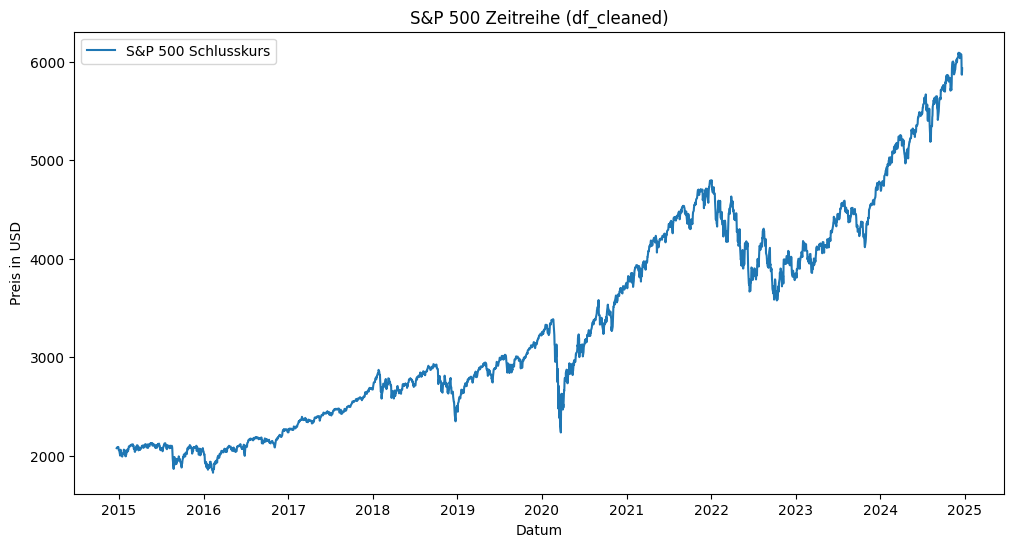

In [552]:
plt.figure(figsize=(12, 6))
plt.plot(df_cleaned.index, df_cleaned['SP500'], label='S&P 500 Schlusskurs')
plt.title('S&P 500 Zeitreihe (df_cleaned)')
plt.xlabel('Datum')
plt.ylabel('Preis in USD')
plt.legend()
plt.show()

In [553]:
summary = df_cleaned.describe().T
head10 = df_cleaned.head(10)

summary, head10


(        count         mean          std      min      25%       50%  \
 SP500  2610.0  3345.529552  1077.892473  1829.08  2426.02  2998.935   
 
              75%      max  
 SP500  4198.8525  6090.27  ,
               SP500
 Date               
 2014-12-22  2078.54
 2014-12-23  2082.17
 2014-12-24  2081.88
 2014-12-25  2081.88
 2014-12-26  2088.77
 2014-12-29  2090.57
 2014-12-30  2080.35
 2014-12-31  2058.90
 2015-01-01  2058.90
 2015-01-02  2058.20)

### 6. Stationarität prüfen (Augmented Dickey-Fuller (ADF) Test)
nutzen wir den ADF-Test, um statistisch zu prüfen, ob die Zeitreihe stationär ist.

Nullhypothese ($H_0$): Die Zeitreihe ist nicht-stationär (besitzt eine Einheitswurzel).

Alternativhypothese ($H_1$): Die Zeitreihe ist stationär.

In [554]:
def print_adf_results(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("=> Die Zeitreihe ist stationär (H0 abgelehnt).")
    else:
        print("=> Die Zeitreihe ist NICHT stationär (H0 kann nicht abgelehnt werden).")

print_adf_results(df_cleaned['SP500'])

ADF Statistic: 0.7068
p-value: 0.9900
=> Die Zeitreihe ist NICHT stationär (H0 kann nicht abgelehnt werden).


### 7. Stationarität durch Differenzierung herstellen
Da Aktienpreise meist nicht stationär sind, müssen wir sie differenzieren ($d$). Wir berechnen die Differenz zwischen aufeinanderfolgenden Tagen. Ergebnis: Wenn der p-Wert nun $\le 0,05$ ist, haben wir unser $d=1$ gefunden.

In [555]:
# Erste Differenzierung (d=1)
df_diff = df_cleaned['SP500'].diff().dropna()

# Erneuter Test der differenzierten Daten
print("Ergebnisse nach der 1. Differenzierung:")
print_adf_results(df_diff)

Ergebnisse nach der 1. Differenzierung:
ADF Statistic: -13.6686
p-value: 0.0000
=> Die Zeitreihe ist stationär (H0 abgelehnt).


### 8. p und q bestimmen (ACF und PACF Plots)
Um die Parameter für den autoregressiven Teil ($p$) und den gleitenden Durchschnitt ($q$) zu finden, nutzen wir die Korrelationsplots:
ACF (Autocorrelation Function): Hilft bei der Bestimmung von $q$.
PACF (Partial Autocorrelation Function): Hilft bei der Bestimmung von $p$.

PACF: Wenn der Plot nach dem ersten Lag (Balken) drastisch abfällt, deutet das auf ein $p=1$ hin.
ACF: Wenn die Korrelation nach dem ersten Lag gegen Null geht, deutet das auf ein $q=1$ hin.

In [556]:
# numerische ACF- und PACF-Werte berechnen
acf_vals = acf(df_diff, nlags=40)
pacf_vals = pacf(df_diff, nlags=40, method='ywm')

print("ACF-Werte (Lag 0..40):")
print(acf_vals)

print("\nPACF-Werte (Lag 0..40):")
print(pacf_vals)

ACF-Werte (Lag 0..40):
[ 1.00000000e+00 -7.69248874e-02  3.87129108e-02 -2.18620167e-02
 -1.57824668e-02  9.11820243e-03 -7.55581397e-02  7.75076009e-02
 -7.10627037e-02  1.34966784e-01 -8.15477666e-02  1.58822046e-02
  1.09090811e-02 -6.19910436e-02  4.08796953e-02 -5.14796166e-02
 -2.04382352e-03 -7.40713600e-03  1.79409319e-02 -4.98900356e-03
 -1.21357856e-02  2.09827026e-02 -4.08451495e-03 -1.87065231e-02
 -2.25677339e-02  2.69958520e-02 -2.96945994e-02 -4.77682926e-02
  4.67021356e-02 -1.01866864e-03 -2.43719596e-02 -1.97572559e-03
 -1.87047903e-02 -9.43447009e-03  3.36396583e-03  1.58462910e-03
 -9.54336637e-04  1.61864606e-02 -1.60090994e-02  1.60465198e-02
 -1.23457911e-02]

PACF-Werte (Lag 0..40):
[ 1.         -0.07692489  0.03299069 -0.01656038 -0.02004592  0.00787256
 -0.07398273  0.06607857 -0.05671627  0.12126932 -0.06355594  0.0019359
  0.01164567 -0.0503575   0.01912783 -0.0205421  -0.03948801  0.01696767
 -0.00472553  0.00447523 -0.00857319  0.00462747  0.01868789 -0.03

In [557]:
acf_vals, acf_conf = acf(df_diff, nlags=40, alpha=0.05)
pacf_vals, pacf_conf = pacf(df_diff, nlags=40, alpha=0.05, method='ywm')

print("ACF Konfidenzintervalle:")
print(acf_conf)

print("\nPACF Konfidenzintervalle:")
print(pacf_conf)


ACF Konfidenzintervalle:
[[ 1.00000000e+00  1.00000000e+00]
 [-1.15296588e-01 -3.85531865e-02]
 [ 1.14815474e-04  7.73110060e-02]
 [-6.05172397e-02  1.67932062e-02]
 [-5.44558906e-02  2.28909571e-02]
 [-2.95647035e-02  4.78011084e-02]
 [-1.14244210e-01 -3.68720693e-02]
 [ 3.86048521e-02  1.16410350e-01]
 [-1.10192160e-01 -3.19332469e-02]
 [ 9.56477649e-02  1.74285802e-01]
 [-1.21543108e-01 -4.15524251e-02]
 [-2.43572066e-02  5.61216157e-02]
 [-2.93395588e-02  5.11577210e-02]
 [-1.02244037e-01 -2.17380504e-02]
 [ 4.86380150e-04  8.12730104e-02]
 [-9.19338014e-02 -1.10254318e-02]
 [-4.25943496e-02  3.85067026e-02]
 [-4.79578138e-02  3.31435418e-02]
 [-2.26117379e-02  5.84936018e-02]
 [-4.55533585e-02  3.55753513e-02]
 [-5.27010440e-02  2.84294727e-02]
 [-1.95879011e-02  6.15533062e-02]
 [-4.46710939e-02  3.65020640e-02]
 [-5.92937073e-02  2.18806610e-02]
 [-6.31676107e-02  1.80321429e-02]
 [-1.36224909e-02  6.76141948e-02]
 [-7.03393514e-02  1.09501525e-02]
 [-8.84449747e-02 -7.09161043e

Die Werte sehen insgesamt so aus, wie man es nach einer Differenzierung einer Aktienzeitreihe erwarten würde: keine starken, systematischen Autokorrelationen mehr, also ungefähr „weißes Rauschen“

### Deine ACF-Werte
Lag 1: etwa −0,077
−0,077 → leicht negative Autokorrelation in der ersten Differenz, aber relativ klein.

Die restlichen Lags liegen überwiegend zwischen etwa −0,08 und +0,13, ohne klares Muster (kein langsames Abklingen, kein konstantes Vorzeichen usw.).

Das deutet eher auf keinen stark ausgeprägten MA-Anteil hin (kein Abschneiden der ACF nach einem kleinen Lag q). []

### Interpretation:
Die differenzierte Reihe scheint näherungsweise stationär zu sein. Es gibt keine klar dominierende Struktur in der ACF, also keinen offensichtlichen reinen MA(q)-Prozess kleiner Ordnung.

### Deine PACF-Werte
Lag 1: etwa −0,077 → kleiner negativer AR‑Effekt erster Ordnung, aber wieder relativ schwach.
Danach sind die PACF-Werte alle in einem ähnlichen kleinen Bereich und schneiden nicht „hart“ nach einem bestimmten p ab (also kein Muster „groß bei Lag 1..p, danach ~0“). []

### Interpretation:
Es gibt keinen klaren Hinweis auf einen „reinen“ AR(p)-Prozess niedriger Ordnung.
Dass sowohl ACF als auch PACF relativ schnell um 0 herum „ausrauschen“, passt eher zu einem ARMA‑ähnlichen oder nahezu weißen Rauschen nach der Differenzierung.

Wenn du ARIMA(p,d,q) bestimmst und die Differenzierung bereits gemacht hast (d=1), dann liefern deine ACF/PACF-Plots keinen starken Hinweis, dass p oder q größer als 1 sein müssten. [][]
Typische sinnvolle Kandidaten wären z.B. ARIMA(0,1,1), ARIMA(1,1,0) oder ARIMA(1,1,1); die endgültige Wahl triffst du dann über Informationskriterien (AIC/BIC) und Residuenchecks. []

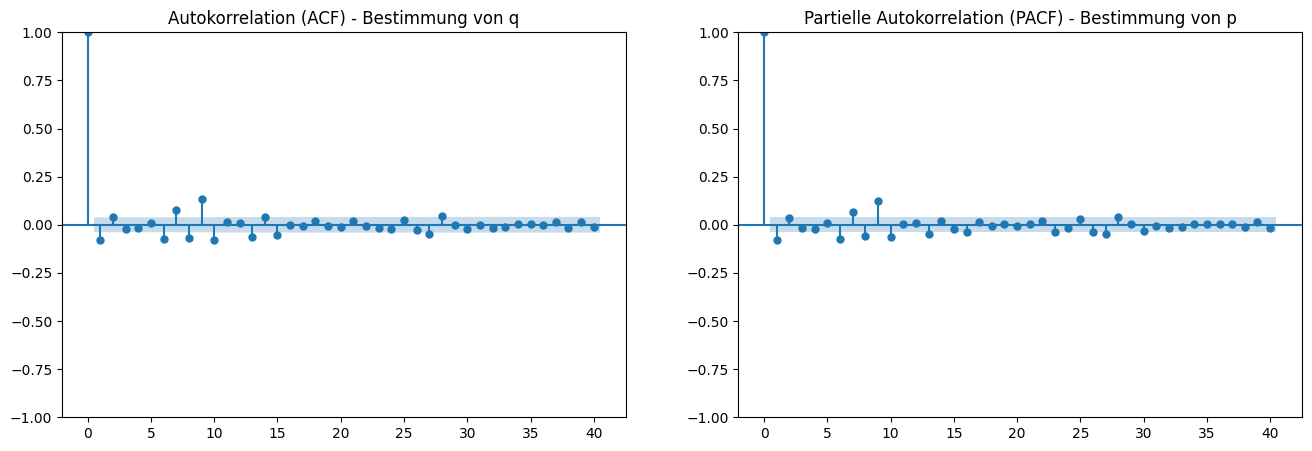

In [558]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF Plot für q
plot_acf(df_diff, ax=axes[0], lags=40)
axes[0].set_title('Autokorrelation (ACF) - Bestimmung von q')

# PACF Plot für p
plot_pacf(df_diff, ax=axes[1], lags=40)
axes[1].set_title('Partielle Autokorrelation (PACF) - Bestimmung von p')

plt.show()

### 9. ARIMA Modell bauen

In [559]:
# Modell definieren
arima_model = ARIMA(df_cleaned['SP500'], order=(1, 1, 1))
arima_result = arima_model.fit()

# Zusammenfassung anzeigen
print(arima_result.summary())

# Vorhersage für die nächsten 5 Tage
forecast_arima = arima_result.get_forecast(steps=5)
print(forecast_arima.summary_frame())

                               SARIMAX Results                                
Dep. Variable:                  SP500   No. Observations:                 2610
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -13087.494
Date:                Mon, 05 Jan 2026   AIC                          26180.987
Time:                        18:54:32   BIC                          26198.587
Sample:                    12-22-2014   HQIC                         26187.363
                         - 12-20-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3972      0.098     -4.066      0.000      -0.589      -0.206
ma.L1          0.3215      0.102      3.167      0.002       0.123       0.521
sigma2      1333.6005     17.974     74.197      0.0

### 10. S ARIMA bauen
S-ARIMA berücksichtigt zusätzlich saisonale Muster. Da Aktienmärkte oft wöchentliche Zyklen haben, testen wir eine Saisonalität von $s=5$ (5 Handelstage pro Woche).

In [560]:
# S-ARIMA mit wöchentlicher Saisonalität (s=5)
sarima_model = SARIMAX(df_cleaned['SP500'],
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 5))
sarima_result = sarima_model.fit()

print(sarima_result.summary())

# Vorhersage für die nächsten 5 Tage
forecast_sarima = sarima_result.get_forecast(steps=5)
print(forecast_sarima.summary_frame())

                                     SARIMAX Results                                     
Dep. Variable:                             SP500   No. Observations:                 2610
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 5)   Log Likelihood              -13078.011
Date:                           Mon, 05 Jan 2026   AIC                          26166.023
Time:                                   18:54:33   BIC                          26195.347
Sample:                               12-22-2014   HQIC                         26176.647
                                    - 12-20-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3914      0.099     -3.943      0.000      -0.586      -0.197
ma.L1          0.3148      0.104      3.040

### 12. Vergleich
Um zu entscheiden, welches Modell "das beste" ist, vergleichen wir den RMSE (Root Mean Squared Error) auf einem Test-Datensatz. Prüfe, ob die Fehler (Residuen) deines Modells

In [561]:
#ARIMA
# Beispiel: Wir vergleichen die letzten 5 Tage (Test-Daten)
test_data = df_cleaned['SP500'][-5:]
predictions_arima = forecast_arima.predicted_mean

rmse_arima = np.sqrt(mean_squared_error(test_data, predictions_arima))
print(f"ARIMA RMSE: {rmse_arima:.2f}")

# (Wiederhole dies für S-ARIMA zum Vergleich)
#S ARIMA
test_data = df_cleaned['SP500'][-5:]
predictions_sarima = forecast_sarima.predicted_mean

rmse_arima = np.sqrt(mean_squared_error(test_data, predictions_sarima))
print(f"ARIMA RMSE: {rmse_arima:.2f}")

ARIMA RMSE: 93.08
ARIMA RMSE: 92.98


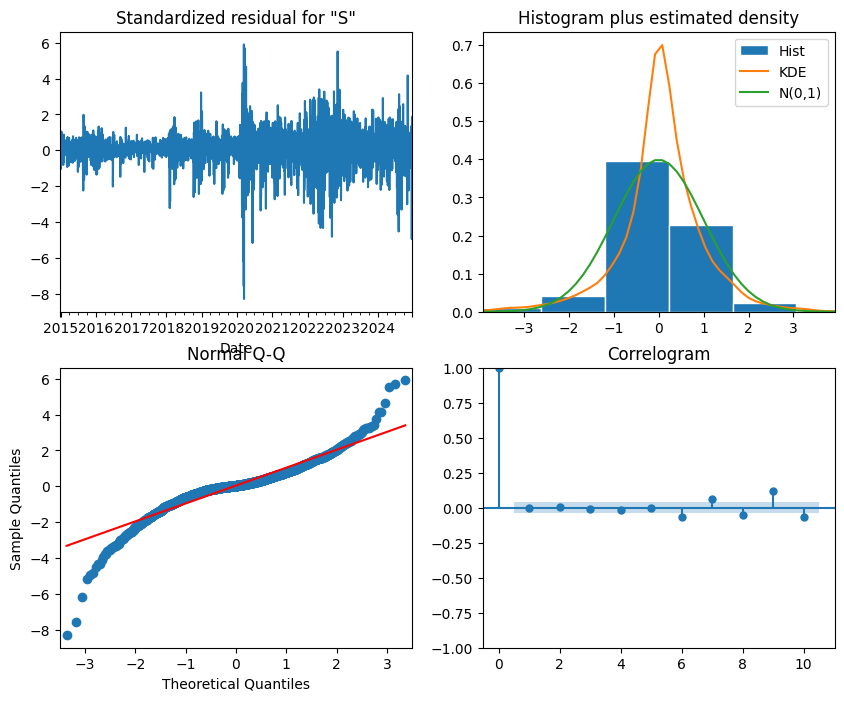

In [562]:
# Plot der Residuen
arima_result.plot_diagnostics(figsize=(10, 8))
plt.show()

### 13. Vergleich mit REal-Daten

In [563]:
# Wir nehmen die letzten 10 Tage als Test-Set
train = df_cleaned['SP500'][:-10]
test = df_cleaned['SP500'][-10:]

print(f"Trainingstage: {len(train)}, Testtage: {len(test)}")

Trainingstage: 2600, Testtage: 10


In [564]:
# ARIMA (p,d,q)
arima_mod = ARIMA(train, order=(1,1,1))
arima_res = arima_mod.fit()
arima_forecast = arima_res.get_forecast(steps=10)
arima_mean = arima_forecast.predicted_mean
arima_ci = arima_forecast.conf_int() # Konfidenzintervall

# SARIMA (p,d,q)(P,D,Q,s)
sarima_mod = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,5))
sarima_res = sarima_mod.fit(disp=False)
sarima_forecast = sarima_res.get_forecast(steps=10)
sarima_mean = sarima_forecast.predicted_mean
sarima_ci = sarima_forecast.conf_int()

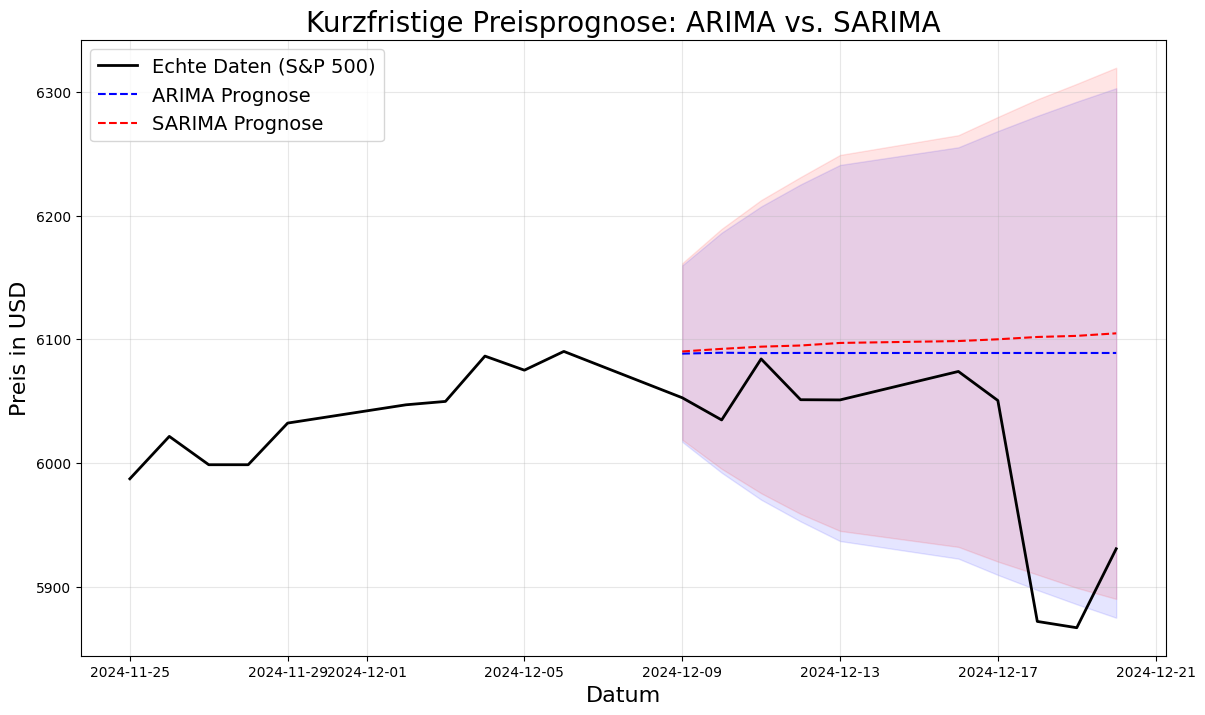

In [565]:
plt.figure(figsize=(14, 8))

# 1. Echte Daten (letzte 30 Tage zur Übersicht)
plt.plot(df_cleaned['SP500'][-20:], label='Echte Daten (S&P 500)', color='black', linewidth=2)

# 2. ARIMA Vorhersage
plt.plot(arima_mean, label='ARIMA Prognose', color='blue', linestyle='--')
plt.fill_between(arima_ci.index, arima_ci.iloc[:, 0], arima_ci.iloc[:, 1], color='blue', alpha=0.1)

# 3. SARIMA Vorhersage
plt.plot(sarima_mean, label='SARIMA Prognose', color='red', linestyle='--')
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], color='red', alpha=0.1)

# Styling für das Poster (große Schrift)
plt.title('Kurzfristige Preisprognose: ARIMA vs. SARIMA', fontsize=20)
plt.xlabel('Datum', fontsize=16)
plt.ylabel('Preis in USD', fontsize=16)
plt.legend(fontsize=14, loc='upper left')
plt.grid(True, alpha=0.3)

plt.show()

In [566]:
# Differenz zwischen Prognose und Istwert für jeden Tag
diff_arima = arima_mean - test
diff_sarima = sarima_mean - test

print(diff_arima)
print(diff_sarima)

2024-12-09     35.631140
2024-12-10     54.307854
2024-12-11      4.724450
2024-12-12     37.789402
2024-12-13     37.897943
2024-12-16     14.929136
2024-12-17     38.390408
2024-12-18    216.844002
2024-12-19    221.922522
2024-12-20    158.153131
Freq: B, dtype: float64
2024-12-09     37.371383
2024-12-10     57.413530
2024-12-11      9.910781
2024-12-12     43.793257
2024-12-13     46.023546
2024-12-16     24.557773
2024-12-17     49.453694
2024-12-18    229.771642
2024-12-19    235.747267
2024-12-20    174.024135
Freq: B, dtype: float64


### 90 Tage test

In [567]:
# Nach ffill: 90 Kalendertage = 90 Datenpunkte
n_test = 90
train = df_cleaned['SP500'][:-n_test]
test = df_cleaned['SP500'][-n_test:]

print(f"Trainingstage: {len(train)}, Testtage: {len(test)}")

Trainingstage: 2520, Testtage: 90


In [568]:
# Forecast für 90 Tage
arima_forecast = arima_res.get_forecast(steps=90)
sarima_forecast = sarima_res.get_forecast(steps=90)

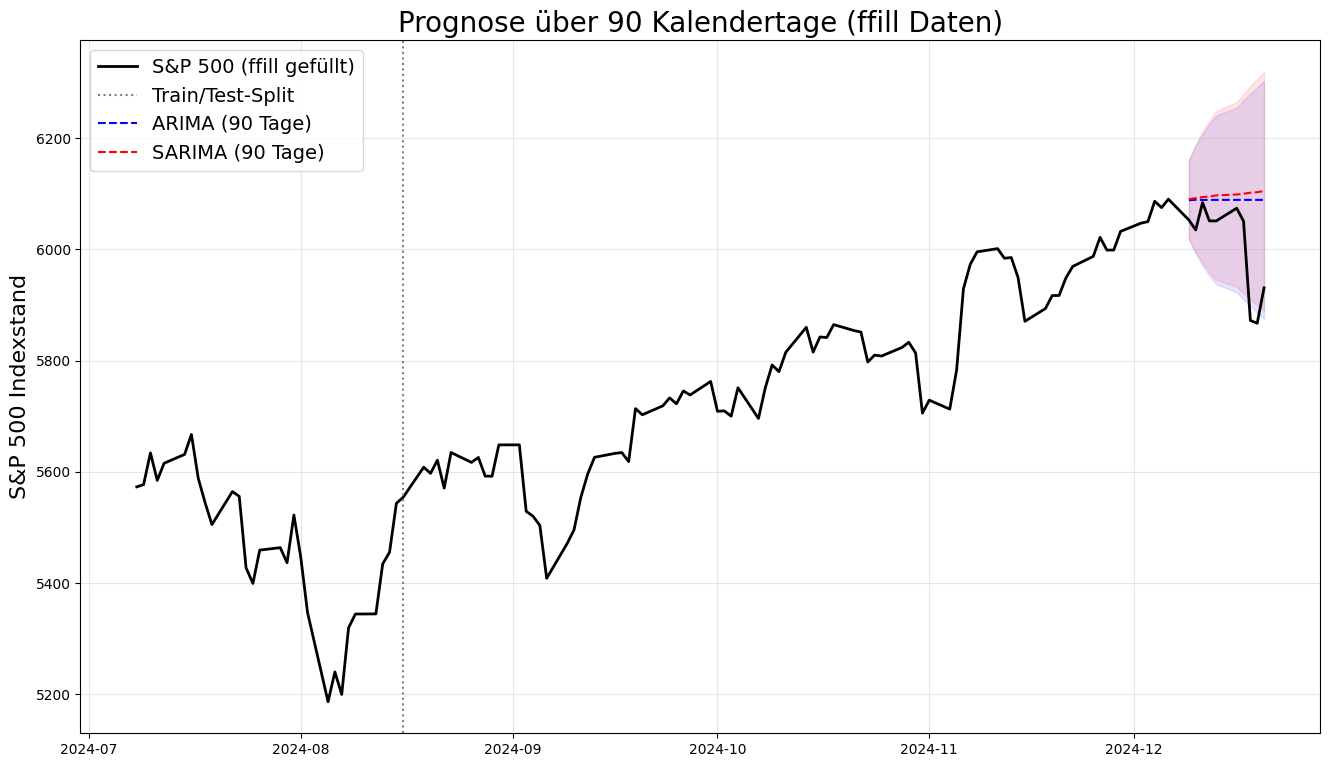

In [569]:
plt.figure(figsize=(16, 9))

# Letzte 120 Kalendertage für Kontext
plt.plot(df_cleaned['SP500'][-120:], label='S&P 500 (ffill gefüllt)', color='black', linewidth=2)
plt.axvline(x=train.index[-1], color='gray', linestyle=':', label='Train/Test-Split')

# Prognosen
plt.plot(arima_mean, label='ARIMA (90 Tage)', color='blue', linestyle='--')
plt.fill_between(arima_ci.index, arima_ci.iloc[:, 0], arima_ci.iloc[:, 1], color='blue', alpha=0.1)

plt.plot(sarima_mean, label='SARIMA (90 Tage)', color='red', linestyle='--')
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], color='red', alpha=0.1)

plt.title('Prognose über 90 Kalendertage (ffill Daten)', fontsize=20)
plt.ylabel('S&P 500 Indexstand', fontsize=16)
plt.legend(fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()